In [26]:
import numpy as np
import pandas as pd


In [27]:
data = pd.read_csv("data.csv",encoding='latin')


/tmp/ipython-input-576979696.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("data.csv",encoding='latin')


In [28]:
data.head()

,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,1990-02-01
1,151.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,1990-02-01
2,152.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,1990-02-01
3,150.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,1990-03-01
4,151.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,1990-03-01


x is a clean array of NO₂ **values**

In [29]:
x = data['no2'].dropna().values

The transformation:

Adds non-linearity

Makes the distribution unknown

Forces us to learn the PDF from data only

In [30]:
r = 102317165

ar = 0.5 * (r % 7)
br = 0.3 * ((r % 5) + 1) #adding 1 to avoid zero

z = x + ar * np.sin(br * x)


In [31]:
# !pip install torch

In [32]:
import torch
import torch.nn as nn


Inherits from nn.Module, which is required for all PyTorch models.

In [33]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)


Its job is to classify real vs fake samples.

In [34]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__() #nitializes the parent nn.Module
        self.net = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


Binary Cross Entropy Loss

Used for binary classification (real vs fake).

Adam optimizer updates network weights.

Learning rate is kept small for stability.

In [35]:
G = Generator()
D = Discriminator()

criterion = nn.BCELoss()
opt_G = torch.optim.Adam(G.parameters(), lr=0.05)
opt_D = torch.optim.Adam(D.parameters(), lr=0.05)


Generator produces fake samples.

Discriminator loss =
real classified as real + fake classified as fake

Generator wants discriminator to believe fake samples are real

zero_grad() →clear previous mistakes

backward() →learning

step() → weight change

In [36]:
z_tensor = torch.tensor(z, dtype=torch.float32).view(-1, 1)
epochs = 5000
for epoch in range(epochs):

    real_labels = torch.ones(z_tensor.size(0), 1)
    fake_labels = torch.zeros(z_tensor.size(0), 1)

    noise = torch.randn(z_tensor.size(0), 1)
    fake_data = G(noise) #Generator produces fake samples.

    D_real = D(z_tensor)
    D_fake = D(fake_data.detach())

    loss_D = criterion(D_real, real_labels) + criterion(D_fake, fake_labels)

    opt_D.zero_grad()
    loss_D.backward()
    opt_D.step()

    noise = torch.randn(z_tensor.size(0), 1)
    fake_data = G(noise)
    D_fake = D(fake_data)

    loss_G = criterion(D_fake, real_labels)

    opt_G.zero_grad()
    loss_G.backward()
    opt_G.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, D Loss: {loss_D.item()}, G Loss: {loss_G.item()}")


Epoch 0, D Loss: 1.524094581604004, G Loss: 0.5411568284034729
Epoch 500, D Loss: 1.3828316926956177, G Loss: 0.6975488662719727
Epoch 1000, D Loss: 1.3827269077301025, G Loss: 0.6957076787948608
Epoch 1500, D Loss: 1.3818786144256592, G Loss: 0.6962996125221252
Epoch 2000, D Loss: 1.3852672576904297, G Loss: 0.6940056085586548
Epoch 2500, D Loss: 1.3837409019470215, G Loss: 0.6949855089187622
Epoch 3000, D Loss: 1.3837268352508545, G Loss: 0.6949996948242188
Epoch 3500, D Loss: 1.3837233781814575, G Loss: 0.6950036287307739
Epoch 4000, D Loss: 1.3837218284606934, G Loss: 0.6950054168701172
Epoch 4500, D Loss: 1.3837207555770874, G Loss: 0.6950058341026306


Histogram approximates the probability density function.

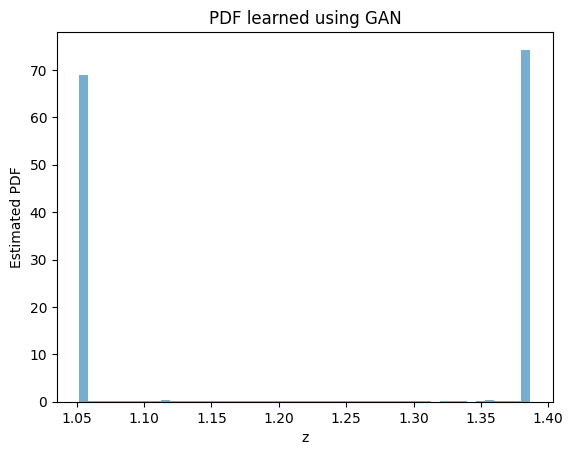

In [37]:
import matplotlib.pyplot as plt
with torch.no_grad():
    samples = G(torch.randn(5000, 1)).numpy()
plt.hist(samples, bins=50, density=True, alpha=0.6)
plt.xlabel("z")
plt.ylabel("Estimated PDF")
plt.title("PDF learned using GAN")
plt.show()
